<a href="https://colab.research.google.com/github/GodishalaAshwith/DeepLearning/blob/main/DLlabCycle2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7

### LeNet - 5

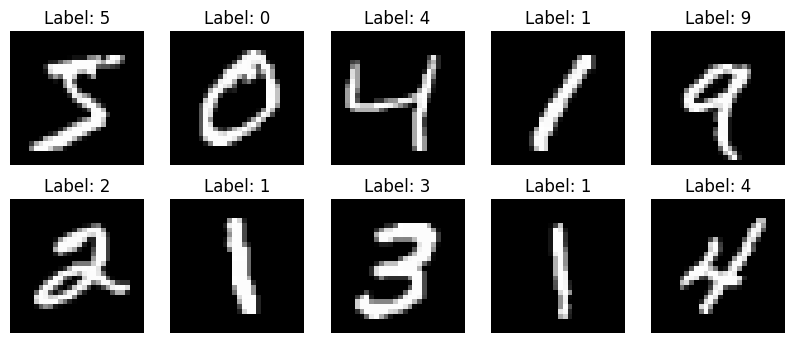

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.8913 - loss: 0.3837 - val_accuracy: 0.9422 - val_loss: 0.1925
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9557 - loss: 0.1459 - val_accuracy: 0.9665 - val_loss: 0.1143
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9689 - loss: 0.0997 - val_accuracy: 0.9726 - val_loss: 0.0958
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9767 - loss: 0.0746 - val_accuracy: 0.9765 - val_loss: 0.0737
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9813 - loss: 0.0601 - val_accuracy: 0.9785 - val_loss: 0.0688
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9843 - loss: 0.0499 - val_accuracy: 0.9815 - val_loss: 0.0624
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9870 - loss: 0.0416 - val_accuracy: 0.9788 - val_loss: 0.0646
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9884 - loss: 0.0369 - val_accuracy: 

In [ ]:
#Import Necessary Libraries
import keras
import keras.utils
from keras import datasets, layers, models
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Activation
import matplotlib.pyplot as plt

#Load Dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

#Visualize The Training Data

plt.figure(figsize=(10, 4))  # Set The size Of The Figure
for i in range(10):
    plt.subplot(2, 5, i + 1)  # Make subplots for 10 images
    plt.imshow(x_train[i], cmap='gray')  # Display The grayscale images
    plt.title(f"Label: {y_train[i]}")  # Add labels
    plt.axis('off')  # Axis Labels Turned Off
plt.show()  # Displaying the plot


#Data Processing
#Split The Data Into Training And Validation Set
#Here, we will split the data into the training and validation set.

# Consider The First 50000 samples As The Training Dataset
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]

# Conside The Last 10000 Samples AS The Validation Dataset
x_val = x_train[50000:]
y_val = y_train[50000:]


#Normalize the Data
x_train_main = x_train_main / 255.0
x_val=x_val/255.0
x_test = x_test / 255.0

#Reshape data
#Change the shape of the arrays to include the color channel of the images. Since the images are grayscale, the color channel is 1.


x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)


#One Hot Encoding
#Perform one-hot encoding to convert categorical data into binary vectors.
#Each element in the binary vector corresponds to a class, and only one element is 1, while the rest are 0.
#For example, if there are 10 classes and the label is 3, the one-hot encoded vector would be [0, 0, 0, 1, 0, 0, 0, 0, 0, 0].

y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)



#Build LeNet5 Model
#Create An Instance of Sequential Class.
LeNet5_Model=Sequential()

# Add First Convolutional Layer
LeNet5_Model.add(Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(28, 28, 1)))

# Add First Average Pooling Layer
LeNet5_Model.add(AveragePooling2D((2, 2)))

# Add Second Convolutional Layer
LeNet5_Model.add(Conv2D(16, kernel_size=(5, 5), activation='tanh'))

# Add Second Average Pooling Layer
LeNet5_Model.add(AveragePooling2D((2, 2)))

# Flatten The Layer
LeNet5_Model.add(Flatten())

# Add Dense Layer
LeNet5_Model.add(Dense(120, activation='tanh'))
LeNet5_Model.add(Dense(84, activation='tanh'))
LeNet5_Model.add(Dense(10, activation='softmax'))

#Compile The Model
LeNet5_Model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


#Check Model Summary
LeNet5_Model.summary()


#Train The Model
LeNet5_Model.fit(x_train_main, y_train_main, epochs=20, batch_size=128, validation_data=(x_val, y_val))


#Evaluate The Model Performance On The Test Dataset
test_loss, test_acc = LeNet5_Model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)







### LeNet with Data Augmentation
Accuracy decreases ! why ?
Because large amount of data makes it harder to process, MNIST is already good enough to achieve 99% accuracy

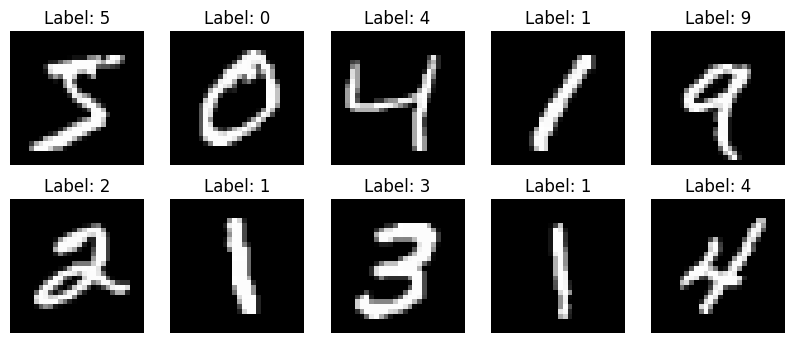

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.7297 - loss: 0.8539 - val_accuracy: 0.9334 - val_loss: 0.2230
Epoch 2/20
  1/390 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8906 - loss: 0.3966

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8906 - loss: 0.3966 - val_accuracy: 0.9318 - val_loss: 0.2247
Epoch 3/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.9142 - loss: 0.2850 - val_accuracy: 0.9604 - val_loss: 0.1286
Epoch 4/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9531 - loss: 0.1874 - val_accuracy: 0.9638 - val_loss: 0.1203
Epoch 5/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.9438 - loss: 0.1830 - val_accuracy: 0.9737 - val_loss: 0.0893
Epoch 6/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9219 - loss: 0.1883 - val_accuracy: 0.9727 - val_loss: 0.0920
Epoch 7/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.9531 - loss: 0.1480 - val_accuracy: 0.9767 - val_loss: 0.0771
Epoch 8/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9609 - loss: 0.1280 - val_accuracy: 0.9762 - val_loss: 0.0775
Epoch 9/20
390/390 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.9603 - loss: 0.1270 - val_accuracy: 0.981

In [ ]:
# Import Necessary Libraries
import keras
from keras import datasets
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Load Dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# Visualize Training Data
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

# -------------------------------
# Data Processing
# -------------------------------

# Split into Training and Validation
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]

x_val = x_train[50000:]
y_val = y_train[50000:]

# Normalize
x_train_main = x_train_main / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0

# Reshape
x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

# One-Hot Encoding
y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# -------------------------------
# Data Augmentation
# -------------------------------
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(x_train_main)

# -------------------------------
# Build LeNet-5 Model
# -------------------------------
model = Sequential()

# C1
model.add(Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(28, 28, 1)))

# S2
model.add(AveragePooling2D((2, 2)))

# C3
model.add(Conv2D(16, kernel_size=(5, 5), activation='tanh'))

# S4
model.add(AveragePooling2D((2, 2)))

# Flatten
model.add(Flatten())

# Fully Connected Layers
model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))
model.add(Dense(10, activation='softmax'))

# Compile
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Summary
model.summary()

# -------------------------------
# Train Model with Augmentation
# -------------------------------
batch_size = 128

history = model.fit(
    datagen.flow(x_train_main, y_train_main, batch_size=batch_size),
    steps_per_epoch=len(x_train_main) // batch_size,
    epochs=20,
    validation_data=(x_val, y_val)
)

# -------------------------------
# Evaluate Model
# -------------------------------
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

###LeNET with Filter Visualization

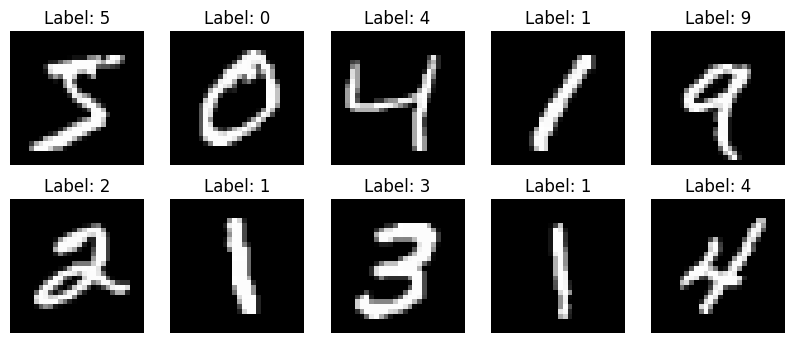

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8850 - loss: 0.3998 - val_accuracy: 0.9480 - val_loss: 0.1818
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9535 - loss: 0.1528 - val_accuracy: 0.9647 - val_loss: 0.1144
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9689 - loss: 0.1012 - val_accuracy: 0.9722 - val_loss: 0.0906
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9772 - loss: 0.0755 - val_accuracy: 0.9777 - val_loss: 0.0749
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9815 - loss: 0.0598 - val_accuracy: 0.9772 - val_loss: 0.0753
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9844 - loss: 0.0509 - val_accuracy: 0.9804 - val_loss: 0.0622
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9872 - loss: 0.0419 - val_accuracy: 0.9829 - val_loss: 0.0578
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9890 - loss: 0.0368 - val_accuracy: 0

AttributeError: The layer sequential_5 has never been called and thus has no defined input.

In [ ]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import keras
from keras import datasets
from keras.models import Sequential, Model
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# 2. LOAD DATA
# ==============================
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# ==============================
# 3. VISUALIZE SAMPLE DATA
# ==============================
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

# ==============================
# 4. DATA PREPROCESSING
# ==============================

# Split
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]
x_val = x_train[50000:]
y_val = y_train[50000:]

# Normalize
x_train_main = x_train_main / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0

# Reshape
x_train_main = x_train_main.reshape(-1, 28, 28, 1)
x_val = x_val.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# ==============================
# 5. BUILD LENET-5 MODEL
# ==============================
model = Sequential()

model.add(Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(28, 28, 1)))
model.add(AveragePooling2D((2, 2)))

model.add(Conv2D(16, kernel_size=(5, 5), activation='tanh'))
model.add(AveragePooling2D((2, 2)))

model.add(Flatten())
model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))
model.add(Dense(10, activation='softmax'))

# Compile
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Summary
model.summary()

# ==============================
# 6. TRAIN MODEL
# ==============================
model.fit(
    x_train_main, y_train_main,
    epochs=10,
    batch_size=128,
    validation_data=(x_val, y_val)
)

# ==============================
# 7. EVALUATE MODEL
# ==============================
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# ==============================
# 8. 🔬 FILTER VISUALIZATION
# ==============================

# Create a model that outputs intermediate layers
layer_outputs = [layer.output for layer in model.layers if "conv" in layer.name]
activation_model = Model(inputs=model.input, outputs=layer_outputs)

# Select one test image
sample_image = x_test[0].reshape(1, 28, 28, 1)

# Get activations
activations = activation_model.predict(sample_image)

# ==============================
# 9. PLOT FEATURE MAPS
# ==============================
layer_names = [layer.name for layer in model.layers if "conv" in layer.name]

for layer_name, layer_activation in zip(layer_names, activations):
    num_filters = layer_activation.shape[-1]

    size = layer_activation.shape[1]

    print(f"\nVisualizing Layer: {layer_name}")

    plt.figure(figsize=(12, 6))

    # Plot all filters
    for i in range(num_filters):
        plt.subplot(1, num_filters, i + 1)
        plt.imshow(layer_activation[0, :, :, i], cmap='viridis')
        plt.axis('off')

    plt.suptitle(f"{layer_name} Feature Maps")
    plt.show()

# ==============================
# 10. 🔬 OPTIONAL: VISUALIZE KERNEL WEIGHTS
# ==============================

# Visualizing actual learned filters (weights)
filters, biases = model.layers[0].get_weights()

plt.figure(figsize=(10, 5))
for i in range(filters.shape[-1]):
    f = filters[:, :, 0, i]
    plt.subplot(1, filters.shape[-1], i + 1)
    plt.imshow(f, cmap='gray')
    plt.axis('off')

plt.suptitle("First Layer Learned Filters")
plt.show()

### AlexNet

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,767,882 (94.48 MB)

 Trainable params: 24,767,882 (94.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 98s 10ms/step - accuracy: 0.1108 - loss: 2.3022 - val_accuracy: 0.1135 - val_loss: 2.3014
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 71s 9ms/step - accuracy: 0.1118 - loss: 2.3015 - val_accuracy: 0.1028 - val_loss: 2.3016
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 75s 10ms/step - accuracy: 0.1111 - loss: 2.3015 - val_accuracy: 0.1135 - val_loss: 2.3012
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 71s 9ms/step - accuracy: 0.1122 - loss: 2.3015 - val_accuracy: 0.1135 - val_loss: 2.3012
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 71s 9ms/step - accuracy: 0.1121 - loss: 2.3015 - val_accuracy: 0.1135 - val_loss: 2.3014
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.1135 - loss: 2.3014
Test accuracy: 0.11349999904632568


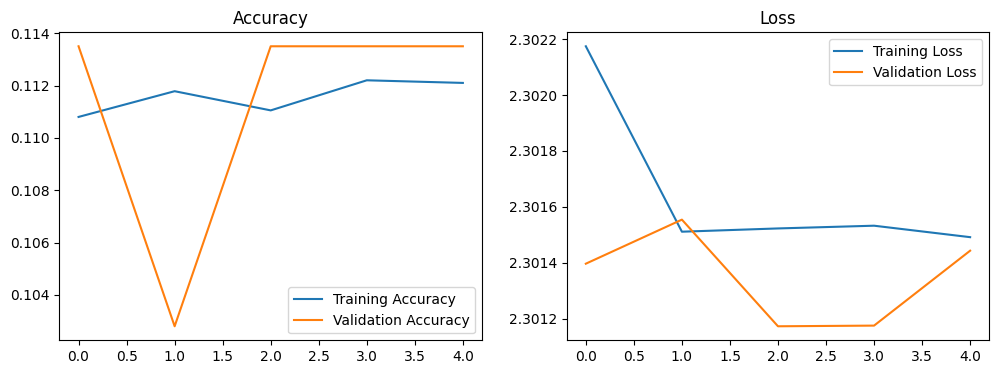

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
import matplotlib.pyplot as plt
import gc

# Clear previous session to free memory
keras.backend.clear_session()

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Preprocess images
x_train = tf.expand_dims(x_train, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)

# Use 112x112 instead of 224x224 (reduces memory usage)
def process_image(image, label):
    image = tf.image.grayscale_to_rgb(image)  # Convert grayscale to RGB
    image = tf.image.resize(image, (112, 112))  # Resize to 112x112
    return image / 255.0, tf.one_hot(label, 10)

# Create dataset pipeline with smaller batch size (8 or 16)
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(process_image).batch(8).shuffle(1000).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.map(process_image).batch(8).prefetch(tf.data.AUTOTUNE)

# Enable mixed precision (reduces memory usage)
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Build AlexNet model (with 112x112 input shape)
model = Sequential()

# Layer 1: Convolution + MaxPooling
model.add(Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=(112, 112, 3)))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))

# Layer 2: Convolution + MaxPooling
model.add(Conv2D(256, (5, 5), padding='same', activation='relu'))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))

# Layer 3-5: Convolution Layers
model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D((3, 3), strides=(2, 2)))

# Flatten + Fully Connected Layers
model.add(Flatten())
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

# Compile model (use Adam optimizer and mixed precision)
model.compile(optimizer=keras.optimizers.Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()

# Train model (with reduced batch size)
history = model.fit(train_dataset, epochs=5, validation_data=test_dataset)

# Evaluate model
test_loss, test_acc = model.evaluate(test_dataset)
print('Test accuracy:', test_acc)

# Clear memory after training
gc.collect()

# Plot Accuracy and Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()


### ZFNET

In [ ]:
# Import Libraries
import keras
from keras import datasets
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

# Load MNIST Dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape (add channel dimension)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# -------------------------------
# Build ZFNet (Adapted for MNIST)
# -------------------------------
model = Sequential()

# Conv1 (ZFNet uses large filters, we reduce size)
model.add(Conv2D(32, (5,5), strides=1, activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Conv2
model.add(Conv2D(64, (3,3), activation='relu'))
# Removed MaxPooling2D(pool_size=(2,2)) here to prevent premature dimension reduction

# Conv3
model.add(Conv2D(128, (3,3), activation='relu'))

# Conv4
model.add(Conv2D(128, (3,3), activation='relu'))

# Conv5
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layers (ZFNet style)
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

# Output
model.add(Dense(10, activation='softmax'))

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
model.summary()

# -------------------------------
# Train
# -------------------------------
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1
)

# -------------------------------
# Evaluate
# -------------------------------
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 6, 6, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 4, 4, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 580,042 (2.21 MB)

 Trainable params: 580,042 (2.21 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.8956 - loss: 0.3253 - val_accuracy: 0.9823 - val_loss: 0.0557
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9787 - loss: 0.0750 - val_accuracy: 0.9897 - val_loss: 0.0334
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9846 - loss: 0.0527 - val_accuracy: 0.9875 - val_loss: 0.0438
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9882 - loss: 0.0415 - val_accuracy: 0.9890 - val_loss: 0.0356
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9894 - loss: 0.0365 - val_accuracy: 0.9925 - val_loss: 0.0256
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9916 - loss: 0.0287 - val_accuracy: 0.9938 - val_loss: 0.0230
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9916 - loss: 0.0289 - val_accuracy: 0.9922 - val_loss: 0.0265
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9929 - loss: 0.0242 - val_accuracy: